<a href="https://colab.research.google.com/github/Mariam30-9/SE-tut2/blob/main/CIB_Projectlatest3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
from google.colab import files

uploaded = files.upload()

Saving credit-card_customers.xlsx to credit-card_customers (2).xlsx


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#plt.style.use("seaborn")

df = pd.read_excel("credit-card_customers.xlsx")
df.head(5000)

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,45,1979-06-09,F,3,High School,Married,Less than $40K,Blue,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.469
1,3708093408,Attrited Customer,58,1966-05-28,M,0,Unknown,Single,$40K - $60K,Blue,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.736
2,3708094683,Attrited Customer,46,1978-06-29,M,3,Doctorate,Divorced,$80K - $120K,Blue,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214
3,3708095583,Existing Customer,34,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000
4,3708097083,Existing Customer,49,1975-03-12,F,2,Uneducated,Married,Unknown,Blue,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,3717103983,Existing Customer,49,1975-01-17,F,2,College,Married,Less than $40K,Blue,...,3,3,2154.0,1490,664.0,0.727,3664,63,0.853,0.692
4996,3717104883,Existing Customer,40,1984-07-11,F,4,Post-Graduate,Married,Unknown,Blue,...,3,1,8823.0,0,8823.0,0.812,4453,84,0.787,0.000
4997,3717105858,Existing Customer,48,1976-03-13,F,4,Unknown,Unknown,Less than $40K,Blue,...,3,4,3212.0,2517,695.0,0.785,4284,69,1.300,0.784
4998,3717106983,Existing Customer,51,1973-04-19,M,2,Doctorate,Single,$40K - $60K,Blue,...,3,3,6492.0,719,5773.0,0.711,4828,78,0.529,0.111


In [106]:
df.shape #To show how many columns and rows  we have
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()] #No duplicates were found based on this line
df.isna().sum() #To show how many missing values in the columns
df.info()#to have a quick look at the columns and data types


Duplicate rows: 401
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12126 entries, 0 to 12125
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Customer_Number           12126 non-null  int64         
 1   Attrition_Flag            12026 non-null  object        
 2   Age                       12126 non-null  int64         
 3   Date_of_birth             12126 non-null  datetime64[ns]
 4   Gender                    11926 non-null  object        
 5   Dependent_count           12126 non-null  int64         
 6   Education_Level           11926 non-null  object        
 7   Marital_Status            12126 non-null  object        
 8   Income_Category           12126 non-null  object        
 9   Card_Category             11924 non-null  object        
 10  Months_on_book            12126 non-null  int64         
 11  Total_Relationship_Count  12126 non-null  int64         
 12

In [107]:
df.describe(include='all') #Was used instead of df.describe() since most columns are in string and it would't work unless with the used function


,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.212600e+04,12026,12126.000000,12126,11926,12126.000000,11926,12126,12126,11924,...,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000,12126.000000
unique,NaN,3,NaN,NaN,2,NaN,7,4,6,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Existing Customer,NaN,NaN,F,NaN,Graduate,Married,Less than $40K,Blue,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,9945,NaN,NaN,6427,NaN,3706,5719,4348,11131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.742948e+09,NaN,46.729672,1977-10-27 07:13:05.551707072,NaN,2.344302,NaN,NaN,NaN,NaN,...,2.347188,2.452251,8268.303224,1178.020122,7231.967829,0.758461,4385.389494,64.732806,0.709325,0.288685
min,3.708092e+09,NaN,5.000000,1904-01-02 00:00:00,NaN,0.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,3.713645e+09,NaN,41.000000,1972-05-01 06:00:00,NaN,1.000000,NaN,NaN,NaN,NaN,...,2.000000,2.000000,2454.500000,465.000000,1197.000000,0.628000,2144.250000,45.000000,0.579000,0.026000
50%,3.719272e+09,NaN,46.000000,1978-03-31 00:00:00,NaN,2.000000,NaN,NaN,NaN,NaN,...,2.000000,2.000000,4182.000000,1293.000000,3224.000000,0.735000,3891.000000,67.000000,0.700000,0.187000
75%,3.779080e+09,NaN,52.000000,1984-03-29 18:00:00,NaN,3.000000,NaN,NaN,NaN,NaN,...,3.000000,3.000000,10572.000000,1800.000000,9575.000000,0.859000,4739.000000,81.000000,0.818000,0.539000
max,3.828353e+09,NaN,120.000000,2014-08-02 00:00:00,NaN,5.000000,NaN,NaN,NaN,NaN,...,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [108]:

categorical_col = []
for column in df.columns:
    if df[column].dtype == object:
        categorical_col.append(column)
        print(f"{column} : {df[column].unique()}")
        print("====================================")
for column in df.columns:
    print(f"{column} : {df[column].unique()}")
    print("====================================")
# To show all unique values of each feature , it helps us to spot right away all the unusual values such as Unknown and nan . It also helps us to know the nature of each columns' values

Attrition_Flag : ['Existing Customer' 'Attrited Customer' nan 'Unknown']
Gender : ['F' 'M' nan]
Education_Level : ['High School' 'Unknown' 'Doctorate' 'Uneducated' 'Graduate' 'College'
 'Post-Graduate' nan]
Marital_Status : ['Married' 'Single' 'Divorced' 'Unknown']
Income_Category : ['Less than $40K' '$40K - $60K' '$80K - $120K' 'Unknown' '$120K +'
 '$60K - $80K']
Card_Category : ['Blue' 'Silver' nan 'Gold' 'Platinum']
Customer_Number : [3708092208 3708093408 3708094683 ... 3828305058 3828309033 3828353208]
Attrition_Flag : ['Existing Customer' 'Attrited Customer' nan 'Unknown']
Age : [ 45  58  46  34  49  43  32  37  55  52  47  56  53  44  48  41  50  35
  62  40  61  26  39  54  64  38  33  51  31  27  57  36  63  30  29  42
  59  65  66   8   7  60 107   6  68 110 111 115  28 113 119 117 108   9
  10 120 114   5 112 104  73 101 103  67 106 118 109 102 116  70]
Date_of_birth : <DatetimeArray>
['1979-06-09 00:00:00', '1966-05-28 00:00:00', '1978-06-29 00:00:00',
 '1990-06-23 00:00:00

In [109]:
df[df.duplicated(keep=False)]

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
32,3708164958,Attrited Customer,39,1985-02-03,F,2,Graduate,Single,Less than $40K,Blue,...,3,3,1438.3,811,627.3,0.571,2336,46,0.278,0.564
33,3708164958,Attrited Customer,39,1985-02-03,F,2,Graduate,Single,Less than $40K,Blue,...,3,3,1438.3,811,627.3,0.571,2336,46,0.278,0.564
58,3708222783,Existing Customer,38,1986-01-12,F,3,Graduate,Married,Less than $40K,Blue,...,3,2,2193.0,1260,933.0,0.886,1799,47,0.567,0.575
59,3708222783,Existing Customer,38,1986-01-12,F,3,Graduate,Married,Less than $40K,Blue,...,3,2,2193.0,1260,933.0,0.886,1799,47,0.567,0.575
106,3708313233,Existing Customer,50,1974-01-22,F,2,Graduate,Married,Less than $40K,Blue,...,3,0,1770.0,1706,64.0,0.626,4940,94,0.774,0.964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11998,3825766458,Existing Customer,55,1969-02-08,F,0,Uneducated,Married,Less than $40K,Blue,...,3,1,2041.0,1885,156.0,0.587,2118,48,0.778,0.924
12062,3827084883,Existing Customer,42,1982-02-12,F,3,Uneducated,Single,Less than $40K,Blue,...,1,4,1538.0,868,670.0,0.828,5228,61,0.694,0.564
12063,3827084883,Existing Customer,42,1982-02-12,F,3,Uneducated,Single,Less than $40K,Blue,...,1,4,1538.0,868,670.0,0.828,5228,61,0.694,0.564
12079,3827418183,Existing Customer,44,1980-04-07,F,3,Graduate,Married,Less than $40K,Blue,...,2,2,2232.0,2002,230.0,1.107,3803,68,0.511,0.897


# Data Cleaning

In [110]:
df = df.drop_duplicates(keep='first')
df
# There were 401 duplicate rows so we had to remove them to eliminate redundancy but we also had to keep the first occurence of each duplicated row

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,45,1979-06-09,F,3,High School,Married,Less than $40K,Blue,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.469
1,3708093408,Attrited Customer,58,1966-05-28,M,0,Unknown,Single,$40K - $60K,Blue,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.736
2,3708094683,Attrited Customer,46,1978-06-29,M,3,Doctorate,Divorced,$80K - $120K,Blue,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214
3,3708095583,Existing Customer,34,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000
4,3708097083,Existing Customer,49,1975-03-12,F,2,Uneducated,Married,Unknown,Blue,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12121,3828298458,Existing Customer,50,1974-03-29,M,0,Uneducated,Married,$60K - $80K,Blue,...,1,3,3640.0,659,2981.0,0.938,3756,70,0.842,0.181
12122,3828301983,Attrited Customer,38,1986-05-15,M,3,College,Single,$60K - $80K,Blue,...,3,4,12050.0,1821,10229.0,0.630,2381,40,0.481,0.151
12123,3828305058,Attrited Customer,49,1975-02-17,F,3,High School,Married,Less than $40K,Blue,...,2,3,2951.0,2437,514.0,0.765,2519,36,0.565,0.826
12124,3828309033,Existing Customer,54,1970-03-04,M,4,Graduate,Married,$120K +,Blue,...,2,0,2872.0,2035,837.0,0.613,1770,47,0.741,0.709


In [111]:
# Categorical value check

print("=== Attrition Flag ===")
print(df["Attrition_Flag"].value_counts(dropna=False))

print("\n=== Gender ===")
print(df["Gender"].value_counts(dropna=False))

print("\n=== Education Level ===")
print(df["Education_Level"].value_counts(dropna=False))

print("\n=== Marital Status ===")
print(df["Marital_Status"].value_counts(dropna=False))


print("\n=== Income Category ===")
print(df["Income_Category"].value_counts(dropna=False))

print("\n=== Card Category ===")
print(df["Card_Category"].value_counts(dropna=False))

#To check how many values are there for each variation in each feature

=== Attrition Flag ===
Attrition_Flag
Existing Customer    9600
Attrited Customer    1925
NaN                   100
Unknown               100
Name: count, dtype: int64

=== Gender ===
Gender
F      6130
M      5395
NaN     200
Name: count, dtype: int64

=== Education Level ===
Education_Level
Graduate         3574
High School      2297
Uneducated       1699
Unknown          1691
College          1153
Post-Graduate     588
Doctorate         523
NaN               200
Name: count, dtype: int64

=== Marital Status ===
Marital_Status
Married     5517
Single      4485
Unknown      867
Divorced     856
Name: count, dtype: int64

=== Income Category ===
Income_Category
Less than $40K    4129
$40K - $60K       2072
$80K - $120K      1755
$60K - $80K       1618
Unknown           1304
$120K +            847
Name: count, dtype: int64

=== Card Category ===
Card_Category
Blue        10730
Silver        639
NaN           202
Gold          132
Platinum       22
Name: count, dtype: int64


In [112]:
today = pd.Timestamp.today()
dob = pd.to_datetime(df['Date_of_birth'])

df['Age'] = today.year - dob.dt.year - (
    (today.month < dob.dt.month) |
    ((today.month == dob.dt.month) & (today.day < dob.dt.day))
)
df

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,47,1979-06-09,F,3,High School,Married,Less than $40K,Blue,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.469
1,3708093408,Attrited Customer,60,1966-05-28,M,0,Unknown,Single,$40K - $60K,Blue,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.736
2,3708094683,Attrited Customer,48,1978-06-29,M,3,Doctorate,Divorced,$80K - $120K,Blue,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214
3,3708095583,Existing Customer,36,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000
4,3708097083,Existing Customer,51,1975-03-12,F,2,Uneducated,Married,Unknown,Blue,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12121,3828298458,Existing Customer,52,1974-03-29,M,0,Uneducated,Married,$60K - $80K,Blue,...,1,3,3640.0,659,2981.0,0.938,3756,70,0.842,0.181
12122,3828301983,Attrited Customer,40,1986-05-15,M,3,College,Single,$60K - $80K,Blue,...,3,4,12050.0,1821,10229.0,0.630,2381,40,0.481,0.151
12123,3828305058,Attrited Customer,51,1975-02-17,F,3,High School,Married,Less than $40K,Blue,...,2,3,2951.0,2437,514.0,0.765,2519,36,0.565,0.826
12124,3828309033,Existing Customer,56,1970-03-04,M,4,Graduate,Married,$120K +,Blue,...,2,0,2872.0,2035,837.0,0.613,1770,47,0.741,0.709


In [113]:
print("Customers younger than 18:", (df["Age"] < 18).sum())
print("Customers older than 100:", (df["Age"] > 100).sum())

Customers younger than 18: 200
Customers older than 100: 196


In [114]:
df.loc[
    (df["Age"] < 18) | (df["Age"] > 100),
    ["Customer_Number", "Age", "Date_of_birth", "Attrition_Flag"]
]

,Customer_Number,Age,Date_of_birth,Attrition_Flag
166,3708424385,13,2012-08-26,Existing Customer
169,3708426605,15,2011-03-09,Attrited Customer
242,3708569905,109,1917-03-07,Existing Customer
268,3708621873,16,2010-02-06,Attrited Customer
332,3708734768,15,2011-04-03,Existing Customer
...,...,...,...,...
12036,3826496816,16,2010-07-15,Existing Customer
12045,3826687132,12,2014-07-23,Existing Customer
12093,3827674170,122,1904-01-11,Existing Customer
12100,3827725142,113,1913-03-10,Existing Customer


In [115]:
missing_rows = df[df.isna().sum(axis=1) > 1].copy()

missing_rows['Missing_Count'] = missing_rows.isna().sum(axis=1)

missing_rows


,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Missing_Count


In [116]:
invalid_balance = df[
    df["Total_Revolving_Bal"] > df["Credit_Limit"]
]

print("Rows where revolving balance > credit limit:",
      len(invalid_balance))

invalid_balance.head(132)

Rows where revolving balance > credit limit: 132


,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
142,3708387503,Existing Customer,56,1970-04-22,M,3,Graduate,Married,$120K +,Blue,...,1,3,0.0,862,33654.0,0.815,15034,111,0.762,0.025
892,3709804762,Existing Customer,51,1975-03-29,M,3,High School,Unknown,$60K - $80K,Blue,...,2,2,0.0,1833,7718.0,1.675,3213,52,1.476,0.192
1013,3710046319,Existing Customer,39,1987-07-18,M,2,Graduate,Married,Less than $40K,Blue,...,3,4,0.0,1687,354.0,0.677,1555,45,0.552,0.827
2210,3712210505,Existing Customer,58,1968-05-25,M,2,High School,Married,$120K +,Blue,...,1,3,0.0,1470,16972.0,0.491,1281,36,0.800,0.080
2491,3712691709,Existing Customer,50,1976-05-29,M,5,Post-Graduate,Single,$60K - $80K,Blue,...,3,2,0.0,1482,4344.0,0.729,4135,76,0.767,0.254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11958,3824402188,Existing Customer,49,1977-06-26,M,3,Graduate,Married,$60K - $80K,Blue,...,1,2,0.0,1251,20080.0,0.949,1460,50,1.083,0.059
11988,3825398397,Attrited Customer,41,1985-01-22,M,2,Uneducated,Single,$60K - $80K,Blue,...,3,3,0.0,1299,12662.0,0.842,783,20,0.667,0.093
12056,3826968581,Existing Customer,51,1975-02-27,M,4,High School,Married,$80K - $120K,Blue,...,3,3,0.0,1076,23180.0,0.568,4269,69,0.643,0.044
12072,3827282243,Attrited Customer,52,1974-03-22,F,2,Uneducated,Single,Unknown,Blue,...,3,2,0.0,2253,498.0,0.497,2108,40,0.481,0.819


# CREDIT LIMIT W AVG OPEN W REVLOVING BALANCE

In [117]:
df['Credit_Limit'] = (
    df['Total_Revolving_Bal'] + df['Avg_Open_To_Buy']
)
df

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,47,1979-06-09,F,3,High School,Married,Less than $40K,Blue,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.469
1,3708093408,Attrited Customer,60,1966-05-28,M,0,Unknown,Single,$40K - $60K,Blue,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.736
2,3708094683,Attrited Customer,48,1978-06-29,M,3,Doctorate,Divorced,$80K - $120K,Blue,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214
3,3708095583,Existing Customer,36,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000
4,3708097083,Existing Customer,51,1975-03-12,F,2,Uneducated,Married,Unknown,Blue,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12121,3828298458,Existing Customer,52,1974-03-29,M,0,Uneducated,Married,$60K - $80K,Blue,...,1,3,3640.0,659,2981.0,0.938,3756,70,0.842,0.181
12122,3828301983,Attrited Customer,40,1986-05-15,M,3,College,Single,$60K - $80K,Blue,...,3,4,12050.0,1821,10229.0,0.630,2381,40,0.481,0.151
12123,3828305058,Attrited Customer,51,1975-02-17,F,3,High School,Married,Less than $40K,Blue,...,2,3,2951.0,2437,514.0,0.765,2519,36,0.565,0.826
12124,3828309033,Existing Customer,56,1970-03-04,M,4,Graduate,Married,$120K +,Blue,...,2,0,2872.0,2035,837.0,0.613,1770,47,0.741,0.709


In [118]:
df[df["Customer_Number"] == 3708387503]

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
142,3708387503,Existing Customer,56,1970-04-22,M,3,Graduate,Married,$120K +,Blue,...,1,3,34516.0,862,33654.0,0.815,15034,111,0.762,0.025


In [119]:
df["Avg_Utilization_Ratio"] = (
    df["Total_Revolving_Bal"] / df["Credit_Limit"]
)
df

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,47,1979-06-09,F,3,High School,Married,Less than $40K,Blue,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.468679
1,3708093408,Attrited Customer,60,1966-05-28,M,0,Unknown,Single,$40K - $60K,Blue,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.735750
2,3708094683,Attrited Customer,48,1978-06-29,M,3,Doctorate,Divorced,$80K - $120K,Blue,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214459
3,3708095583,Existing Customer,36,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000000
4,3708097083,Existing Customer,51,1975-03-12,F,2,Uneducated,Married,Unknown,Blue,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12121,3828298458,Existing Customer,52,1974-03-29,M,0,Uneducated,Married,$60K - $80K,Blue,...,1,3,3640.0,659,2981.0,0.938,3756,70,0.842,0.181044
12122,3828301983,Attrited Customer,40,1986-05-15,M,3,College,Single,$60K - $80K,Blue,...,3,4,12050.0,1821,10229.0,0.630,2381,40,0.481,0.151120
12123,3828305058,Attrited Customer,51,1975-02-17,F,3,High School,Married,Less than $40K,Blue,...,2,3,2951.0,2437,514.0,0.765,2519,36,0.565,0.825822
12124,3828309033,Existing Customer,56,1970-03-04,M,4,Graduate,Married,$120K +,Blue,...,2,0,2872.0,2035,837.0,0.613,1770,47,0.741,0.708565


In [120]:
df[df["Customer_Number"] == 3708095583]

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
3,3708095583,Existing Customer,36,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.0


In [121]:
df[df["Customer_Number"] == 3708095583]

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
3,3708095583,Existing Customer,36,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.0


In [122]:
#removing nan and unknown from attrition flag
df = df[
    df['Attrition_Flag'].isin([
        'Existing Customer',
        'Attrited Customer'
    ])
].copy()
df

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,47,1979-06-09,F,3,High School,Married,Less than $40K,Blue,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.468679
1,3708093408,Attrited Customer,60,1966-05-28,M,0,Unknown,Single,$40K - $60K,Blue,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.735750
2,3708094683,Attrited Customer,48,1978-06-29,M,3,Doctorate,Divorced,$80K - $120K,Blue,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214459
3,3708095583,Existing Customer,36,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000000
4,3708097083,Existing Customer,51,1975-03-12,F,2,Uneducated,Married,Unknown,Blue,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12121,3828298458,Existing Customer,52,1974-03-29,M,0,Uneducated,Married,$60K - $80K,Blue,...,1,3,3640.0,659,2981.0,0.938,3756,70,0.842,0.181044
12122,3828301983,Attrited Customer,40,1986-05-15,M,3,College,Single,$60K - $80K,Blue,...,3,4,12050.0,1821,10229.0,0.630,2381,40,0.481,0.151120
12123,3828305058,Attrited Customer,51,1975-02-17,F,3,High School,Married,Less than $40K,Blue,...,2,3,2951.0,2437,514.0,0.765,2519,36,0.565,0.825822
12124,3828309033,Existing Customer,56,1970-03-04,M,4,Graduate,Married,$120K +,Blue,...,2,0,2872.0,2035,837.0,0.613,1770,47,0.741,0.708565


In [123]:
df.groupby('Card_Category')['Credit_Limit'].agg(
    ['min', 'median', 'mean', 'max']
)

,min,median,mean,max
Card_Category,,,,
Blue,1438.3,4097.0,7386.290794,34516.0
Gold,3735.0,34516.0,28506.648438,34516.0
Platinum,15987.0,34516.0,30283.450000,34516.0
Silver,3735.0,28564.0,24834.023923,34516.0


In [124]:
print("=== Attrition Flag ===")
print(df["Attrition_Flag"].value_counts(dropna=False))

print("\n=== Gender ===")
print(df["Gender"].value_counts(dropna=False))

print("\n=== Education Level ===")
print(df["Education_Level"].value_counts(dropna=False))

print("\n=== Marital Status ===")
print(df["Marital_Status"].value_counts(dropna=False))


print("\n=== Income Category ===")
print(df["Income_Category"].value_counts(dropna=False))

print("\n=== Card Category ===")
print(df["Card_Category"].value_counts(dropna=False))

=== Attrition Flag ===
Attrition_Flag
Existing Customer    9600
Attrited Customer    1925
Name: count, dtype: int64

=== Gender ===
Gender
F      6008
M      5317
NaN     200
Name: count, dtype: int64

=== Education Level ===
Education_Level
Graduate         3524
High School      2253
Uneducated       1665
Unknown          1657
College          1127
Post-Graduate     586
Doctorate         513
NaN               200
Name: count, dtype: int64

=== Marital Status ===
Marital_Status
Married     5425
Single      4411
Unknown      851
Divorced     838
Name: count, dtype: int64

=== Income Category ===
Income_Category
Less than $40K    4065
$40K - $60K       2044
$80K - $120K      1735
$60K - $80K       1576
Unknown           1266
$120K +            839
Name: count, dtype: int64

=== Card Category ===
Card_Category
Blue        10548
Silver        627
NaN           202
Gold          128
Platinum       20
Name: count, dtype: int64


In [125]:
df["Gender"] = df["Gender"].fillna("Unknown")
df["Gender"].value_counts(dropna=False)

df["Education_Level"] = df["Education_Level"].fillna("Unknown")
df["Education_Level"].value_counts(dropna=False)

df["Card_Category"] = df["Card_Category"].fillna("Unknown")
df["Card_Category"].value_counts(dropna=False)


,count
Card_Category,
Blue,10548
Silver,627
Unknown,202
Gold,128
Platinum,20


In [126]:
df.loc[
    (df["Age"] < 18) &
    (df["Marital_Status"].isin(["Married", "Divorced"])),
    ["Customer_Number", "Age", "Marital_Status", "Education_Level"]
]

,Customer_Number,Age,Marital_Status,Education_Level
166,3708424385,13,Married,Unknown
169,3708426605,15,Married,Unknown
268,3708621873,16,Married,High School
332,3708734768,15,Married,College
566,3709171561,14,Married,High School
...,...,...,...,...
11965,3824638504,17,Married,Doctorate
11967,3824700617,12,Married,Graduate
12036,3826496816,16,Married,Uneducated
12045,3826687132,12,Married,College


In [127]:
df.loc[
    df["Age"] > 100,
    ["Customer_Number", "Age", "Education_Level", "Months_Inactive_12_mon"]
]

,Customer_Number,Age,Education_Level,Months_Inactive_12_mon
242,3708569905,109,High School,3
528,3709105987,112,Graduate,3
561,3709163157,113,Graduate,1
650,3709324339,117,Graduate,2
705,3709426339,115,Graduate,2
...,...,...,...,...
11944,3824119031,119,Uneducated,3
11964,3824635560,121,Uneducated,3
12014,3826109972,106,Graduate,1
12093,3827674170,122,Graduate,3


In [128]:
df["Age"].max()

122

In [129]:
df = df.drop(
    df[
        (df["Age"] < 18) &
        (df["Marital_Status"].isin(["Married", "Divorced"]))
    ].index
)
df[df["Age"] < 18]

,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio


In [130]:
df = df.drop(df[df["Age"] > 100].index)
df[df["Age"] > 100]
df.shape

(11129, 22)

In [131]:
df = df.drop(columns=["Date_of_birth"])
df

,Customer_Number,Attrition_Flag,Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,47,F,3,High School,Married,Less than $40K,Blue,36,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.468679
1,3708093408,Attrited Customer,60,M,0,Unknown,Single,$40K - $60K,Blue,45,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.735750
2,3708094683,Attrited Customer,48,M,3,Doctorate,Divorced,$80K - $120K,Blue,38,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214459
3,3708095583,Existing Customer,36,F,2,Uneducated,Single,Less than $40K,Blue,24,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000000
4,3708097083,Existing Customer,51,F,2,Uneducated,Married,Unknown,Blue,41,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12121,3828298458,Existing Customer,52,M,0,Uneducated,Married,$60K - $80K,Blue,46,...,1,3,3640.0,659,2981.0,0.938,3756,70,0.842,0.181044
12122,3828301983,Attrited Customer,40,M,3,College,Single,$60K - $80K,Blue,34,...,3,4,12050.0,1821,10229.0,0.630,2381,40,0.481,0.151120
12123,3828305058,Attrited Customer,51,F,3,High School,Married,Less than $40K,Blue,45,...,2,3,2951.0,2437,514.0,0.765,2519,36,0.565,0.825822
12124,3828309033,Existing Customer,56,M,4,Graduate,Married,$120K +,Blue,50,...,2,0,2872.0,2035,837.0,0.613,1770,47,0.741,0.708565


# DATA EXPLORATION

In [132]:
df.groupby('Card_Category')['Credit_Limit'].agg(
    ['min', 'median', 'mean', 'max']
)

,min,median,mean,max
Card_Category,,,,
Blue,1438.3,4101.5,7369.579436,34516.0
Gold,3735.0,34516.0,28619.717742,34516.0
Platinum,15987.0,34516.0,30283.450000,34516.0
Silver,3735.0,28822.0,25082.021488,34516.0
Unknown,1438.3,4938.0,8211.199010,34516.0


In [133]:
df['C.Turnover'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

=== Attrition Flag Distribution ===
Attrition_Flag
Existing Customer    9296
Attrited Customer    1833
Name: count, dtype: int64

Percentage:
Attrition_Flag
Existing Customer    83.5
Attrited Customer    16.5
Name: proportion, dtype: float64


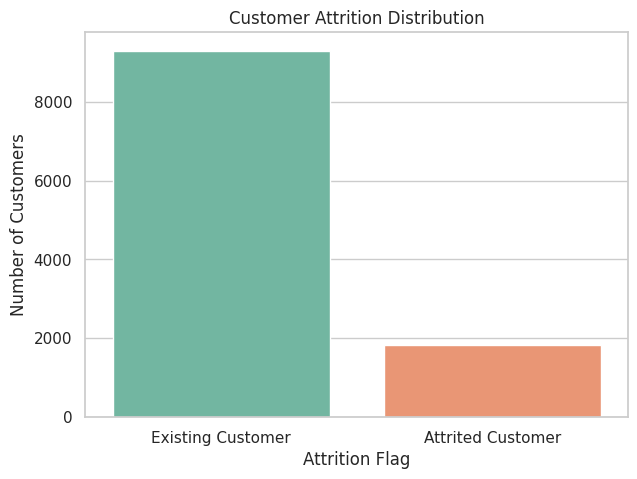

In [134]:
print("=== Attrition Flag Distribution ===")
print(df['Attrition_Flag'].value_counts())
print("\nPercentage:")
print(df['Attrition_Flag'].value_counts(normalize=True).round(3) * 100)

# Visualization
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Attrition_Flag', hue='Attrition_Flag', palette='Set2', legend=False)
plt.title('Customer Attrition Distribution')
plt.xlabel('Attrition Flag')
plt.ylabel('Number of Customers')
plt.show()

/tmp/ipykernel_668/878837981.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gender, x="Gender", y="Credit_Limit", palette=palette)
/tmp/ipykernel_668/878837981.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(["Female", "Male"])


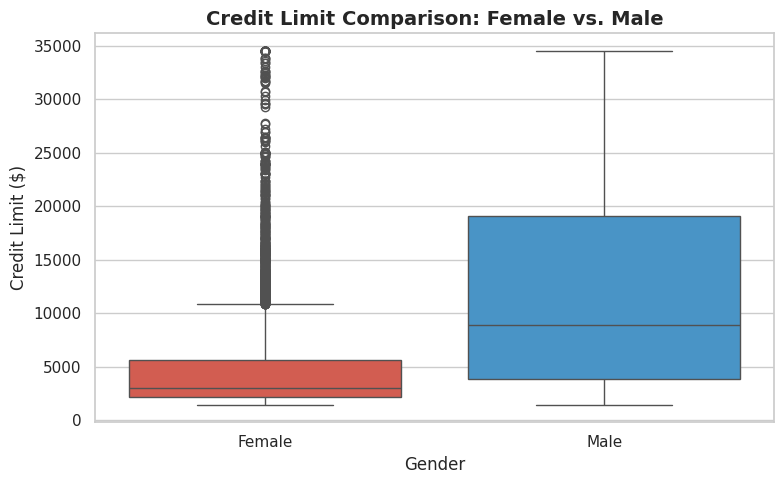

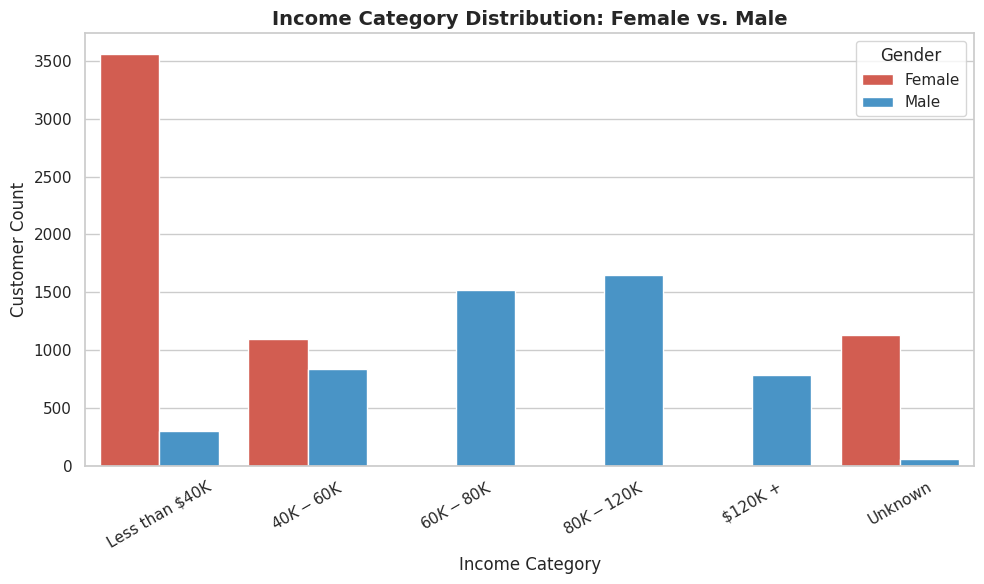

/tmp/ipykernel_668/878837981.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gender, x="Gender", y="Total_Trans_Ct", palette=palette)
/tmp/ipykernel_668/878837981.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(["Female", "Male"])


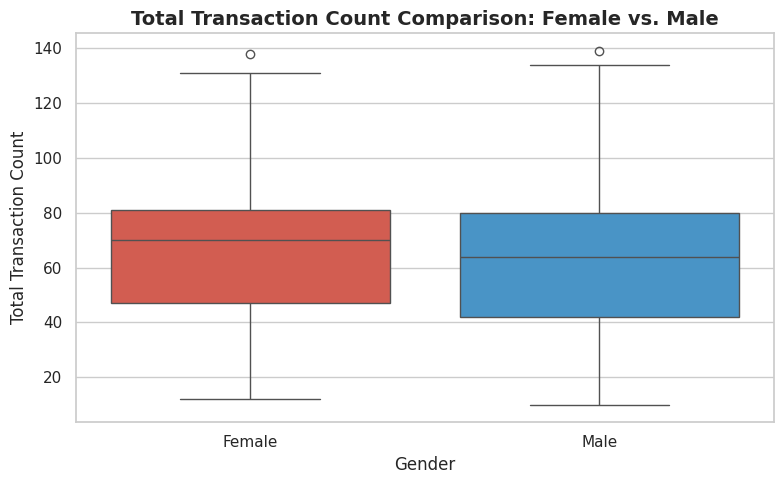

/tmp/ipykernel_668/878837981.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_gender, x="Gender", y="Total_Trans_Amt", palette=palette)
/tmp/ipykernel_668/878837981.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(["Female", "Male"])


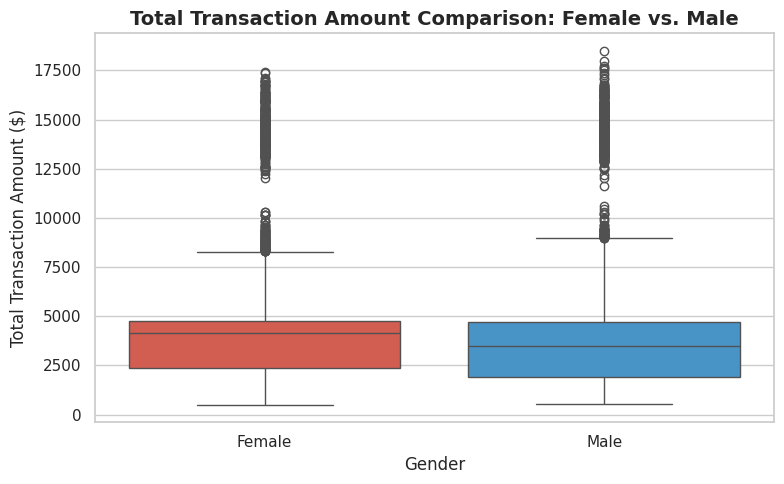

In [135]:
# Filter for Female and Male records only
df_gender = df[df['Gender'].isin(['F', 'M'])].copy()

# Set aesthetic styling
sns.set_theme(style="whitegrid")
palette = {"F": "#e74c3c", "M": "#3498db"} # Red for Female, Blue for Male

# ============================================================
# GRAPH 1: Credit Limit Comparison
# ============================================================
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_gender, x="Gender", y="Credit_Limit", palette=palette)
plt.title("Credit Limit Comparison: Female vs. Male", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Credit Limit ($)", fontsize=12)
plt.gca().set_xticklabels(["Female", "Male"])
plt.tight_layout()
plt.show()

# ============================================================
# GRAPH 2: Income Category Comparison
# ============================================================
plt.figure(figsize=(10, 6))
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']
sns.countplot(data=df_gender, x="Income_Category", hue="Gender", order=income_order, palette=palette)
plt.title("Income Category Distribution: Female vs. Male", fontsize=14, fontweight="bold")
plt.xlabel("Income Category", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="Gender", labels=["Female", "Male"])
plt.tight_layout()
plt.show()

# ============================================================
# GRAPH 3: Total Transaction Count Comparison
# ============================================================
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_gender, x="Gender", y="Total_Trans_Ct", palette=palette)
plt.title("Total Transaction Count Comparison: Female vs. Male", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Total Transaction Count", fontsize=12)
plt.gca().set_xticklabels(["Female", "Male"])
plt.tight_layout()
plt.show()

# ============================================================
# GRAPH 4: Total Transaction Amount Comparison
# ============================================================
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_gender, x="Gender", y="Total_Trans_Amt", palette=palette)
plt.title("Total Transaction Amount Comparison: Female vs. Male", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Total Transaction Amount ($)", fontsize=12)
plt.gca().set_xticklabels(["Female", "Male"])
plt.tight_layout()
plt.show()

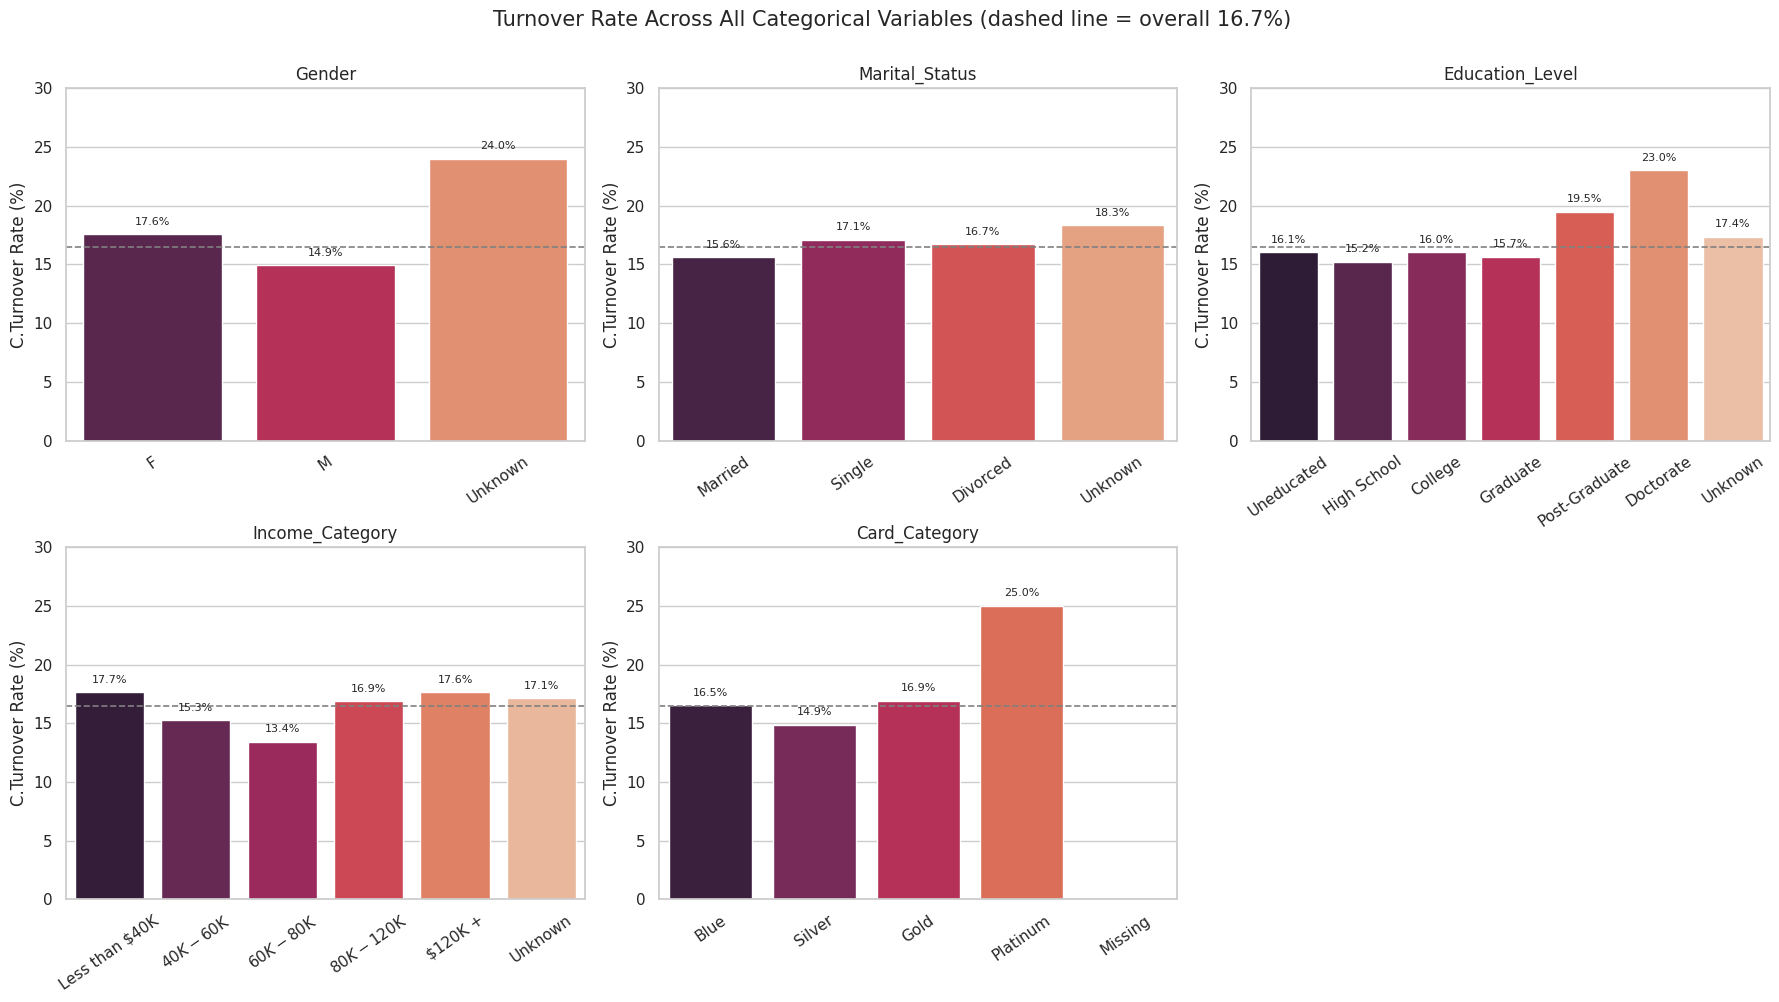

In [136]:


cat_vars = {
    'Gender': ['F', 'M', 'Unknown'],
    'Marital_Status': ['Married', 'Single', 'Divorced', 'Unknown'],
    'Education_Level': ['Uneducated', 'High School', 'College', 'Graduate',
                          'Post-Graduate', 'Doctorate', 'Unknown'],
    'Income_Category': ['Less than $40K', '$40K - $60K', '$60K - $80K',
                          '$80K - $120K', '$120K +', 'Unknown'],
    'Card_Category': ['Blue', 'Silver', 'Gold', 'Platinum', 'Missing']
}

overall_rate = df['C.Turnover'].mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, order) in enumerate(cat_vars.items()):
    ax = axes[i]
    summary = df.groupby(col)['C.Turnover'].agg(['mean', 'count']).reindex(order)
    summary['pct'] = summary['mean'] * 100
    sns.barplot(x=summary.index, y=summary['pct'], hue=summary.index,
                legend=False, palette='rocket', order=order, ax=ax)
    ax.axhline(overall_rate, color='gray', linestyle='--', linewidth=1.2)
    for j, v in enumerate(summary['pct']):
        ax.text(j, v + 0.8, f'{v:.1f}%', ha='center', fontsize=8)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('C.Turnover Rate (%)')
    ax.set_ylim(0, 30)
    ax.tick_params(axis='x', rotation=35)

axes[-1].axis('off')
fig.suptitle('Turnover Rate Across All Categorical Variables (dashed line = overall 16.7%)',
             fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig('turnover_rate_all_categoricals.png', dpi=200, bbox_inches='tight')
plt.show()

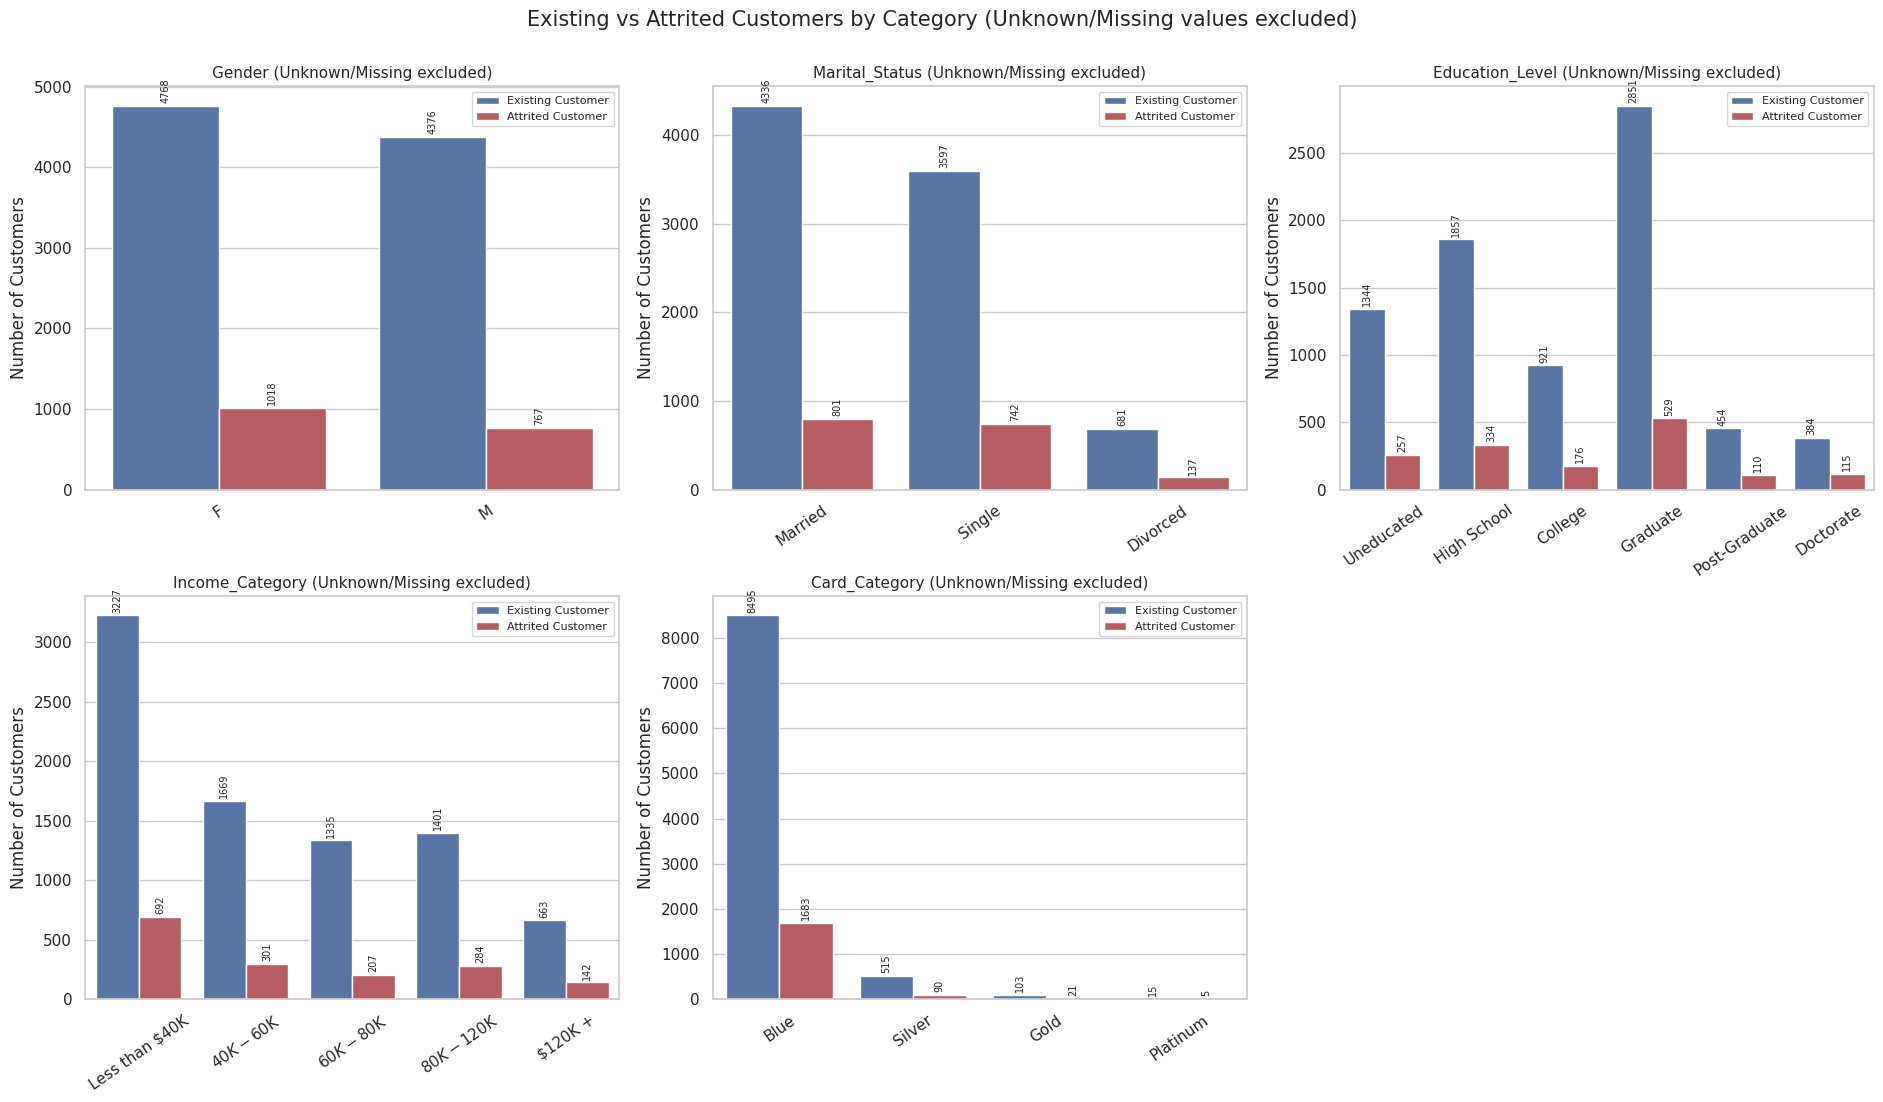

In [137]:


# Each entry: (categories to keep, values to exclude for that column)
cat_vars = {
    'Gender': (['F', 'M'], ['Unknown']),
    'Marital_Status': (['Married', 'Single', 'Divorced'], ['Unknown']),
    'Education_Level': (['Uneducated', 'High School', 'College', 'Graduate',
                           'Post-Graduate', 'Doctorate'], ['Unknown']),
    'Income_Category': (['Less than $40K', '$40K - $60K', '$60K - $80K',
                           '$80K - $120K', '$120K +'], ['Unknown']),
    'Card_Category': (['Blue', 'Silver', 'Gold', 'Platinum'], ['Missing'])
}

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
axes = axes.flatten()

for i, (col, (keep_order, exclude_vals)) in enumerate(cat_vars.items()):
    ax = axes[i]
    # exclude Unknown/Missing AND true NaN, per column, without dropping other columns' rows
    sub = df[~df[col].isin(exclude_vals) & df[col].notna()]
    sns.countplot(data=sub, x=col, hue='Attrition_Flag', order=keep_order,
                  palette={'Existing Customer': '#4C72B0', 'Attrited Customer': '#C44E52'}, ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fontsize=7, rotation=90, padding=2)
    ax.set_title(f'{col} (Unknown/Missing excluded)', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Number of Customers')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='', fontsize=8)

axes[-1].axis('off')
fig.suptitle('Existing vs Attrited Customers by Category (Unknown/Missing values excluded)',
             fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig('count_all_categoricals_no_unknown.png', dpi=200, bbox_inches='tight')
plt.show()
#bar plot was used to show comparison between all categorical variables in each feature

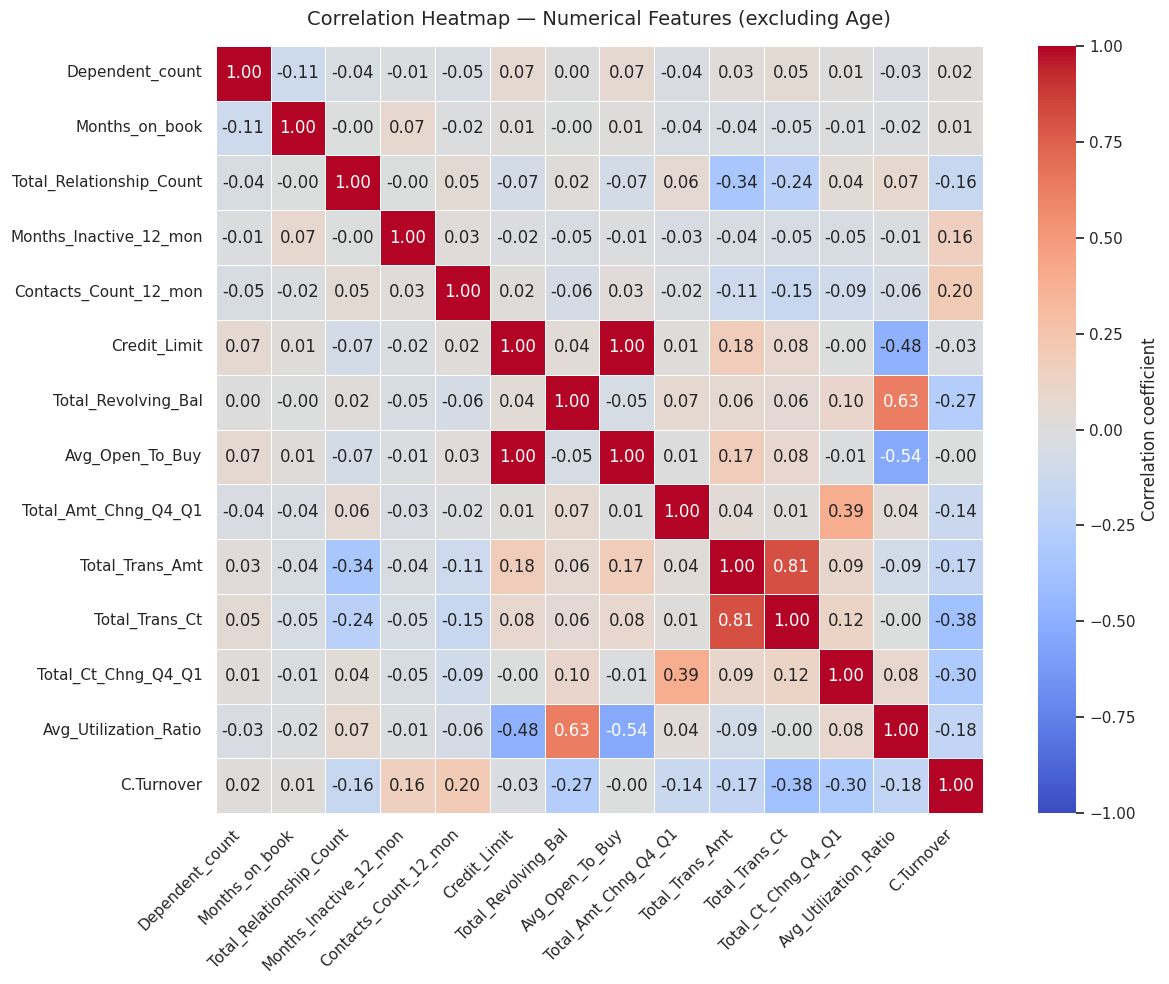

In [138]:



num_cols = ['Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
            'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
            'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
            'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
            'Avg_Utilization_Ratio', 'C.Turnover']

corr = df[num_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Heatmap — Numerical Features (excluding Age)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap_no_age.png', dpi=200)
plt.show()
#heatmap was used to show correlation between all numerical variables and churn.

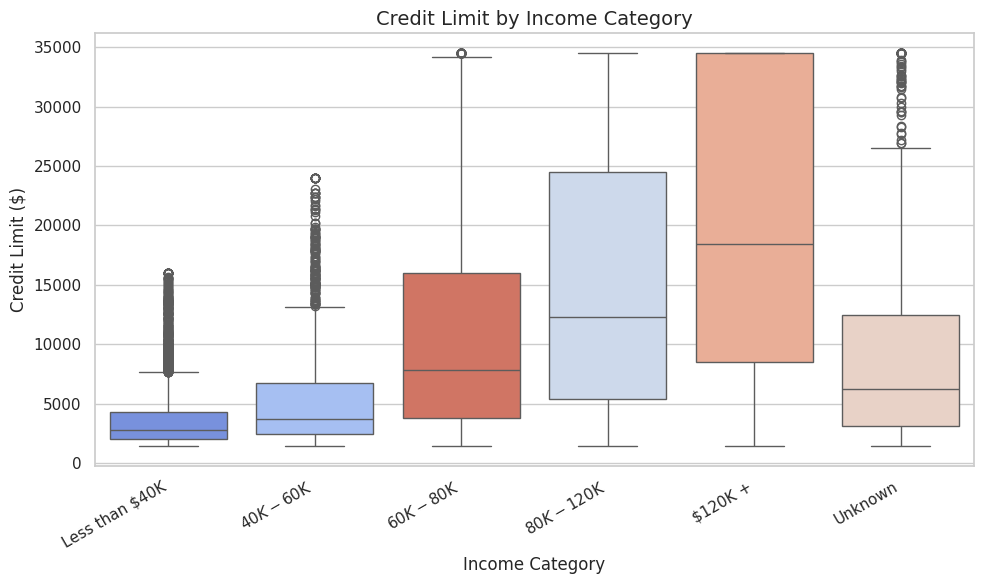

In [139]:
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K',
                 '$80K - $120K', '$120K +', 'Unknown']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Income_Category', y='Credit_Limit',
            order=income_order, hue='Income_Category', legend=False, palette='coolwarm')
plt.title('Credit Limit by Income Category', fontsize=14)
plt.xlabel('Income Category')
plt.ylabel('Credit Limit ($)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('income_vs_creditlimit.png', dpi=200)
plt.show()

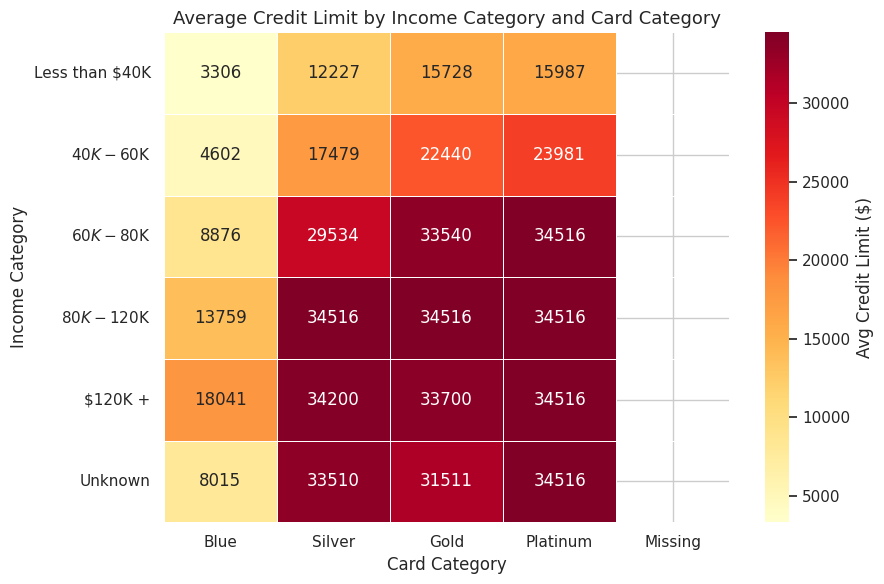

In [140]:
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K',
                 '$80K - $120K', '$120K +', 'Unknown']
card_order = ['Blue', 'Silver', 'Gold', 'Platinum', 'Missing']

pivot = df.pivot_table(values='Credit_Limit', index='Income_Category',
                        columns='Card_Category', aggfunc='mean')
pivot = pivot.reindex(index=income_order, columns=card_order)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Credit Limit ($)'})
plt.title('Average Credit Limit by Income Category and Card Category', fontsize=13)
plt.xlabel('Card Category')
plt.ylabel('Income Category')
plt.tight_layout()
plt.savefig('income_card_creditlimit_heatmap.png', dpi=200)
plt.show()

In [141]:
# High-risk attrited customers:
# low transaction count change + low amount change + high contact count

high_risk_attrited = df[
    (df['Attrition_Flag'] == 'Attrited Customer') &
    (df['Total_Ct_Chng_Q4_Q1'] < 0.60) &
    (df['Total_Amt_Chng_Q4_Q1'] < 0.60) &
    (df['Contacts_Count_12_mon'] >= 3)
]

# View the results
high_risk_attrited[[
    'Customer_Number',
    'Total_Ct_Chng_Q4_Q1',
    'Total_Amt_Chng_Q4_Q1',
    'Contacts_Count_12_mon',
    'Attrition_Flag'

]]


,Customer_Number,Total_Ct_Chng_Q4_Q1,Total_Amt_Chng_Q4_Q1,Contacts_Count_12_mon,Attrition_Flag
2,3708094683,0.000,0.000,3,Attrited Customer
14,3708128058,0.417,0.519,3,Attrited Customer
32,3708164958,0.278,0.571,3,Attrited Customer
111,3708326133,0.074,0.238,3,Attrited Customer
139,3708383208,0.147,0.583,4,Attrited Customer
...,...,...,...,...,...
11837,3821759733,0.594,0.580,3,Attrited Customer
11898,3823512736,0.414,0.527,3,Attrited Customer
11917,3823626108,0.250,0.379,3,Attrited Customer
11945,3824151033,0.000,0.000,4,Attrited Customer


In [142]:
# 1. Filter attrited customers with both low change ratios
subset = df[
    (df['Attrition_Flag'] == 'Attrited Customer') &
    (df['Total_Ct_Chng_Q4_Q1'] < 0.60) &
    (df['Total_Amt_Chng_Q4_Q1'] < 0.60)
]

# 2. Define "low credit limit" (using the median of the whole dataset)
low_limit_threshold = df['Credit_Limit'].median()

# 3. Calculate the percentage
pct_low_credit = (subset['Credit_Limit'] < low_limit_threshold).mean() * 100

print(f"Number of attrited customers with low Ct & Amt change: {len(subset)}")
print(f"Low Credit Limit threshold (median): ${low_limit_threshold:,.0f}")
print(f"% of them with low Credit Limit: {pct_low_credit:.1f}%")

Number of attrited customers with low Ct & Amt change: 493
Low Credit Limit threshold (median): $4,559
% of them with low Credit Limit: 52.7%


# DATA PREPARING FOR MODELLING

In [143]:
df['C.Turnover'].value_counts() #There is an imbalance in the data
df['C.Turnover'].value_counts() / df['C.Turnover'].count() #Where the number of classes of attrited are much more than the number of existing classes #1= attrited customers # existing customers

,count
C.Turnover,
0,0.835295
1,0.164705


In [144]:
#As we will be changing data its best to work on a copy of the cleaned data
df_model = df.copy()

# Gather all categorical predictor variables in one variable for easier encosing
categorical_cols = [
    'Gender',
    'Education_Level',
    'Marital_Status',
    'Income_Category',
    'Card_Category'
]

# One-hot encode categorical variables some of these variables such as Income Category , Card Category , Educational Category are ordinal but as we have unknown values in them its best to use one hot encoding instead of label encoding
# Unknown remains a separate category
df_model = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)


In [145]:
#split
# Target
y = df_model['C.Turnover']

# Predictors
X = df_model.drop(
    columns=[
        'C.Turnover',
        'Attrition_Flag',
        'Customer_Number',
        'Avg_Open_To_Buy'

    ],
    errors='ignore'
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11129, 33)
y shape: (11129,)


In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8903, 33)
X_test: (2226, 33)
y_train: (8903,)
y_test: (2226,)


In [147]:
#scale:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numerical_cols = [
    'Age',
    'Dependent_count',
    'Months_on_book',
    'Total_Relationship_Count',
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Credit_Limit',
    'Total_Revolving_Bal',
    'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

In [148]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Dependent_count',
                                                   'Months_on_book',
                                                   'Total_Relationship_Count',
                                                   'Months_Inactive_12_mon',
                                                   'Contacts_Count_12_mon',
                                                   'Credit_Limit',
                                                   'Total_Revolving_Bal',
                                                   'Total_Amt_Chng_Q4_Q1',
                                                   'Total_Trans_Amt',
                                                   'Total_Trans_Ct',
                                                   'Total_Ct_Chng_Q4_Q1',
                                                   'Avg_Utilization_Ratio'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [149]:
# Make predictions on the test data
y_pred = logistic_model.predict(X_test)

# Get probability of being an Attrited Customer
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions:", y_pred[:10])
print("Attrition probabilities:", y_prob[:10])

Predictions: [0 1 1 1 0 0 0 0 0 0]
Attrition probabilities: [0.02890105 0.98126718 0.96322003 0.98751451 0.00958537 0.039229
 0.35328441 0.00276663 0.23254793 0.42907241]


TRAIN RESULTS - Logistic Regression
Accuracy : 84.84%
              precision    recall  f1-score   support

    Existing       0.97      0.85      0.90      7437
    Attrited       0.52      0.85      0.65      1466

    accuracy                           0.85      8903
   macro avg       0.75      0.85      0.78      8903
weighted avg       0.89      0.85      0.86      8903

TEST RESULTS - Logistic Regression
Accuracy : 85.71%
ROC-AUC  : 0.9304
              precision    recall  f1-score   support

    Existing       0.97      0.86      0.91      1859
    Attrited       0.54      0.86      0.66       367

    accuracy                           0.86      2226
   macro avg       0.76      0.86      0.79      2226
weighted avg       0.90      0.86      0.87      2226



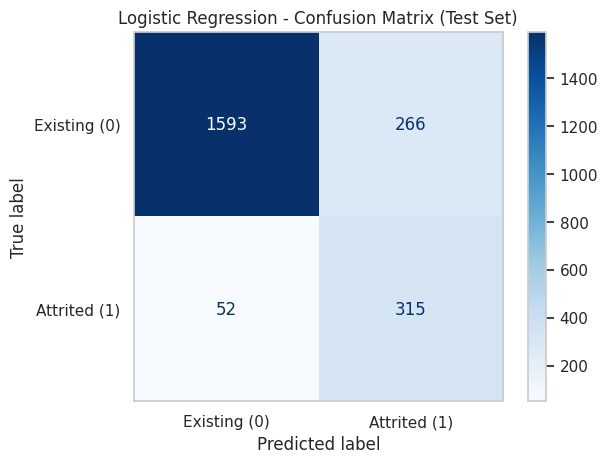

In [150]:
# ============================================================
# EVALUATION - Logistic Regression
# ============================================================

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_logistic_model(model, X_train, y_train, X_test, y_test):
    print("=" * 60)
    print("TRAIN RESULTS - Logistic Regression")
    print("=" * 60)

    y_train_pred = model.predict(X_train)
    print(f"Accuracy : {accuracy_score(y_train, y_train_pred) * 100:.2f}%")
    print(classification_report(
        y_train,
        y_train_pred,
        target_names=['Existing', 'Attrited']
    ))

    print("=" * 60)
    print("TEST RESULTS - Logistic Regression")
    print("=" * 60)

    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    print(f"Accuracy : {accuracy_score(y_test, y_test_pred) * 100:.2f}%")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.4f}")
    print(classification_report(
        y_test,
        y_test_pred,
        target_names=['Existing', 'Attrited']
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Existing (0)', 'Attrited (1)']
    )
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Logistic Regression - Confusion Matrix (Test Set)')
    plt.grid(False)
    plt.show()


# Run the evaluation
evaluate_logistic_model(logistic_model, X_train, y_train, X_test, y_test)

TRAIN RESULTS - Random Forest
Accuracy : 97.85%
              precision    recall  f1-score   support

    Existing       1.00      0.98      0.99      7437
    Attrited       0.89      0.99      0.94      1466

    accuracy                           0.98      8903
   macro avg       0.94      0.98      0.96      8903
weighted avg       0.98      0.98      0.98      8903

TEST RESULTS - Random Forest
Accuracy : 96.23%
ROC-AUC  : 0.9887
              precision    recall  f1-score   support

    Existing       0.98      0.97      0.98      1859
    Attrited       0.87      0.91      0.89       367

    accuracy                           0.96      2226
   macro avg       0.92      0.94      0.93      2226
weighted avg       0.96      0.96      0.96      2226



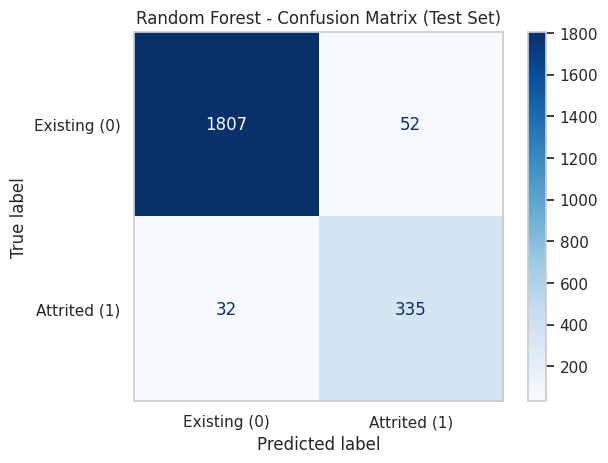


Top 15 Most Important Features:
                 Feature  Importance
          Total_Trans_Ct    0.217720
         Total_Trans_Amt    0.211268
     Total_Revolving_Bal    0.118869
     Total_Ct_Chng_Q4_Q1    0.109390
   Avg_Utilization_Ratio    0.068557
    Total_Amt_Chng_Q4_Q1    0.059085
Total_Relationship_Count    0.039882
  Months_Inactive_12_mon    0.032692
            Credit_Limit    0.032002
   Contacts_Count_12_mon    0.023323
                     Age    0.023121
          Months_on_book    0.019662
                Gender_M    0.008952
         Dependent_count    0.007751
  Marital_Status_Married    0.004215


/tmp/ipykernel_668/2577466737.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')


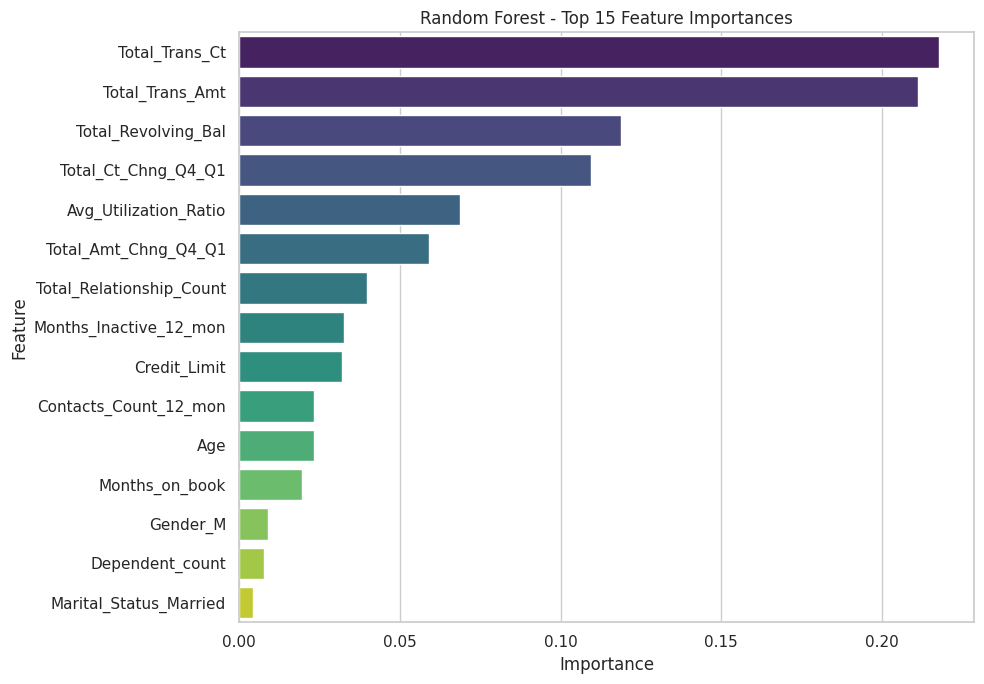

In [151]:
# RANDOM FOREST MODEL (No Scaling needed)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# ============================================================
# EVALUATION - Random Forest
# ============================================================

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    print("=" * 60)
    print(f"TRAIN RESULTS - {model_name}")
    print("=" * 60)
    y_train_pred = model.predict(X_train)
    print(f"Accuracy : {accuracy_score(y_train, y_train_pred)*100:.2f}%")
    print(classification_report(y_train, y_train_pred, target_names=['Existing', 'Attrited']))

    print("=" * 60)
    print(f"TEST RESULTS - {model_name}")
    print("=" * 60)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    print(f"Accuracy : {accuracy_score(y_test, y_test_pred)*100:.2f}%")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.4f}")
    print(classification_report(y_test, y_test_pred, target_names=['Existing', 'Attrited']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Existing (0)', 'Attrited (1)'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{model_name} - Confusion Matrix (Test Set)')
    plt.grid(False)
    plt.show()

evaluate_model(rf_model, X_train, y_train, X_test, y_test, model_name="Random Forest")

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest - Top 15 Feature Importances')
plt.tight_layout()
plt.show()


